<a href="https://colab.research.google.com/github/sharvani1357/hierarch_cluster/blob/main/Hierarchical.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('all-data.csv', encoding='latin1')

In [ ]:
df.head()

,neutral,"According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing ."
0,neutral,Technopolis plans to develop in stages an area...
1,negative,The international electronic industry company ...
2,positive,With the new production plant the company woul...
3,positive,According to the company 's updated strategy f...
4,positive,FINANCING OF ASPOCOMP 'S GROWTH Aspocomp is ag...


In [ ]:
df.isna().sum()

,0
neutral,0
"According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing .",0


In [ ]:
print("Dataset Shape:", df.shape)
print("Columns:", df.columns.tolist())

Dataset Shape: (4845, 2)
Columns: ['neutral', 'According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing .']


In [ ]:
# Step 2: Identify News Text Column
# (Choose the object column with largest average text length)

text_column = None
max_length = 0

for col in df.columns:
    if df[col].dtype == 'object':
        avg_len = df[col].astype(str).apply(len).mean()
        if avg_len > max_length:
            max_length = avg_len
            text_column = col

print("Identified Text Column:", text_column)

Identified Text Column: According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing .


In [ ]:
# Step 3: Convert Text to TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(
    max_features=1000,     # Limit to top 1000 important words
    stop_words='english'   # Remove common English words
)

X_tfidf = tfidf.fit_transform(df[text_column].astype(str))

print("TF-IDF Matrix Shape:", X_tfidf.shape)
print("Number of Features:", len(tfidf.get_feature_names_out()))

TF-IDF Matrix Shape: (4845, 1000)
Number of Features: 1000


Dendrogram Construction & Analysis
Build a dendrogram using a subset of articles
Observe:
Where large vertical jumps occur
What they indicate about topic separation

In [ ]:
import numpy as np
from sklearn.decomposition import TruncatedSVD
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

# Use only first 200 articles (subset for speed)
subset_size = 200
X_subset = X_tfidf[:subset_size]

# Reduce dimensions (important for text data)
svd = TruncatedSVD(n_components=50, random_state=42)
X_reduced = svd.fit_transform(X_subset)


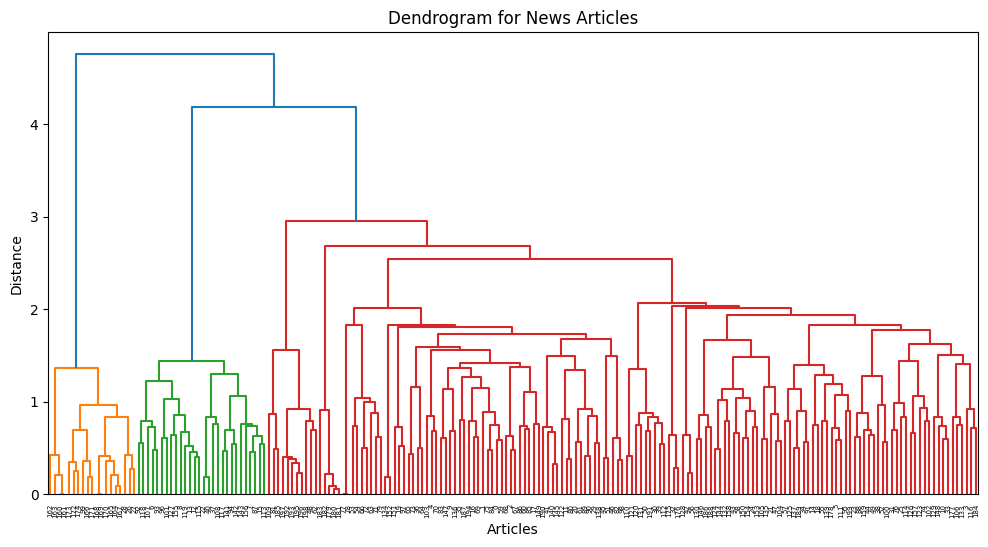

In [ ]:
# Perform hierarchical clustering
linked = linkage(X_reduced, method='ward')

# Plot dendrogram
plt.figure(figsize=(12, 6))
dendrogram(linked)
plt.title("Dendrogram for News Articles")
plt.xlabel("Articles")
plt.ylabel("Distance")
plt.show()


Apply Hierarchical Clustering
Use Agglomerative Hierarchical Clustering
Choose an appropriate linkage method

In [ ]:
from sklearn.decomposition import TruncatedSVD

# Reduce TF-IDF dimensions (good practice for text data)
svd = TruncatedSVD(n_components=50, random_state=42)
X_reduced = svd.fit_transform(X_tfidf)


Step 2: Apply Agglomerative Hierarchical Clustering

We will use:

Linkage Method: ward

Reason:
✔ Works well with Euclidean distance
✔ Produces compact, well-separated clusters
✔ Best choice for text embeddings after SVD

In [ ]:
from sklearn.cluster import AgglomerativeClustering

# Choose number of clusters (example: 5)
n_clusters = 5

hierarchical_model = AgglomerativeClustering(
    n_clusters=n_clusters,
    linkage='ward'
)

# Fit and predict
hier_labels = hierarchical_model.fit_predict(X_reduced)

# Add cluster labels to dataset
df['hierarchical_cluster'] = hier_labels

print("Cluster Counts:")
print(df['hierarchical_cluster'].value_counts())


Cluster Counts:
hierarchical_cluster
4    3324
0     913
3     261
1     233
2     114
Name: count, dtype: int64


Validation Without Labels (Critical Thinking)
Since this is unsupervised:
How do you judge clustering quality?
mertic:
Silhouette score

In [ ]:
from sklearn.metrics import silhouette_score

# Calculate Silhouette Score
score = silhouette_score(X_reduced, hier_labels)

print("Silhouette Score:", score)


Silhouette Score: 0.1466255164477062
